## llm don't have any intrinsic memory


In [1]:
from langgraph.graph import StateGraph,MessagesState,START,END
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

In [3]:
llm = ChatOpenAI(model= 'gpt-4o-mini')

In [4]:
def chatNode(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {'messages':[response]}

In [15]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()

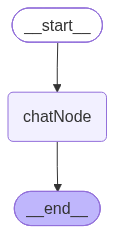

In [16]:
builder = StateGraph(state_schema=MessagesState)
builder.add_node('chatNode',chatNode)
builder.add_edge(START,'chatNode')
builder.add_edge('chatNode',END)

graph = builder.compile(checkpointer=checkpointer)
graph

In [17]:
config1 = {'configurable':{'thread_id':'thread-1'}}
config2 = {'configurable':{'thread_id':'thread-2'}}

In [18]:
from langchain_core.messages import HumanMessage

In [19]:
graph.invoke(input = {
    'messages':[HumanMessage(content = 'hi my name is raju jsohi')]
},config=config1)

{'messages': [HumanMessage(content='hi my name is raju jsohi', additional_kwargs={}, response_metadata={}, id='f87a4bdf-d405-481a-bc36-c3a205ce5492'),
  AIMessage(content='Hello, Raju! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 16, 'total_tokens': 28, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 9.6e-06, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 9.6e-06, 'upstream_inference_prompt_cost': 2.4e-06, 'upstream_inference_completions_cost': 7.2e-06}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_369e662417', 'id': 'gen-1789644693-rGe

In [20]:
graph.invoke(input = {
    'messages':[HumanMessage(content='what is my name')]
},config = config1)

{'messages': [HumanMessage(content='hi my name is raju jsohi', additional_kwargs={}, response_metadata={}, id='f87a4bdf-d405-481a-bc36-c3a205ce5492'),
  AIMessage(content='Hello, Raju! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 16, 'total_tokens': 28, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 9.6e-06, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 9.6e-06, 'upstream_inference_prompt_cost': 2.4e-06, 'upstream_inference_completions_cost': 7.2e-06}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_369e662417', 'id': 'gen-1789644693-rGe

In [23]:
list(graph.get_state_history(config = config1))

[StateSnapshot(values={'messages': [HumanMessage(content='hi my name is raju jsohi', additional_kwargs={}, response_metadata={}, id='f87a4bdf-d405-481a-bc36-c3a205ce5492'), AIMessage(content='Hello, Raju! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 16, 'total_tokens': 28, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 9.6e-06, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 9.6e-06, 'upstream_inference_prompt_cost': 2.4e-06, 'upstream_inference_completions_cost': 7.2e-06}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_369e662417', 'id':

In [24]:
graph.invoke(input ={
    'messages':[HumanMessage(content =' what is my name')]
},config=config2)

{'messages': [HumanMessage(content=' what is my name', additional_kwargs={}, response_metadata={}, id='f28fb705-fc69-4e1b-87ff-3c372d39cf30'),
  AIMessage(content="I'm sorry, but I don't have access to personal information about you unless you've shared it in our conversation. If you tell me your name, I can certainly remember it for our chat!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 11, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 2.385e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 2.385e-05, 'upstream_inference_prompt_cost': 1.65e-06, 'upstream_inference_completions_cost': 2

In [ ]:
list(graph.get_state_history(config=config2))

[StateSnapshot(values={'messages': [HumanMessage(content=' what is my name', additional_kwargs={}, response_metadata={}, id='f28fb705-fc69-4e1b-87ff-3c372d39cf30'), AIMessage(content="I'm sorry, but I don't have access to personal information about you unless you've shared it in our conversation. If you tell me your name, I can certainly remember it for our chat!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 11, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 2.385e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 2.385e-05, 'upstream_inference_prompt_cost': 1.65e-06, 'upstream_inference_

: 

## till now only using the ram to store the memory